## 진행상황

- 중성색에 대한 알고리즘은 아직 구현하지 아니함.
- KOTE 감정범주화에 대응하는 새로운 색상값을 라벨링하는 것으로 연구 방향을 정함.
- 106개의 IRI 이미지 형용사는 아직 정리하지 아니함
- Blossom 프롬프트 엔지니어링 해야함. inpu text에 대한 일관성 부족

## 1. color mapping
#### context engineering 전, dummy를 가지고 색 선정 함수를 정의하고자함.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import colorsys

- KOTE 44가지 감정의 긍/부정/중립 기준 적용

In [9]:
positive_emotions = ['감동/감탄', '고마움', '기대감', '기쁨', '뿌듯함',
'신기함/관심', '아껴주는', '안심/신뢰', '존경', '즐거움/신남', '편안/쾌적', '행복', '환영/호의',
'흐뭇함(귀여움/예쁨)',
]
negative_emotions = ['경악', '공포/무서움', '귀찮음', '당황/난처', '부끄러움', '부담/안_내킴', '불쌍함/연민', '불안/걱정', 
                     '불평/불만', '슬픔', '서러움', '안타까움/실망', '어이없음', '역겨움/징그러움', '의심/불신', '짜증', 
                     '재미없음', '절망', '죄책감', '증오/혐오', '지긋지긋', '패배/자기혐오', '한심함', '화남/분노', '힘듦/지침', '분노']
neutral_emotions = ['깨달음', '놀람', '비장함', '우쭐댐/무시함']

no_emotion = ['없음']

In [10]:
result_emotions_contrast = {'불쌍함/연민': 0.44,
'불안/걱정': 0.56,
'서러움': 0.51,
'부끄러움': 0.7,
'아껴주는' : 0.47,
'안타까움/실망': 0.31,
'없음': 0.8,
'기쁨':0.6
}

result_emotions_similar = {'불쌍함/연민': 0.44,
'불안/걱정': 0.56,
'서러움': 0.63,
'슬픔': 0.7,
'아껴주는' : 0.47,
'안타까움/실망': 0.31,
'없음': 0.8,
'죄책감':0.5
}

result_emotions_similaremotion_contrastcolor = {'불쌍함/연민': 0.44,
'불안/걱정': 0.56,
'서러움': 0.51,
'슬픔': 0.7,
'아껴주는' : 0.47,
'안타까움/실망': 0.31,
'없음': 0.8,
'분노':0.6
}

result_IRI = '사랑스러운'

### KCoED 데이터셋 & IRI 데이터셋 가져오기

In [11]:
# CSV 파일 경로
file_path = "../data/임이로_학위논문_korean emtion-color dataset 3.0 - KOTE참조모델.csv"
# 파일 읽기 (처음엔 컬럼명을 무시하고 불러오기)
df = pd.read_csv(file_path, header=None)

# 첫 번째 행을 컬럼명으로 지정
df.columns = df.iloc[0]
df = df[1:]  # 첫 행은 이제 컬럼으로 사용했으니 제외

In [12]:
# CSV 파일 경로
file_path_IRI = "../data/임이로_학위논문_korean emtion-color dataset 2.0 - IRI-형용사스케일.csv"
# 파일 읽기 (처음엔 컬럼명을 무시하고 불러오기)
df_raw_IRI = pd.read_csv(file_path_IRI, header=None)

# 첫 번째 행을 컬럼명으로 지정
df_raw_IRI.columns = df_raw_IRI.iloc[1]
df_IRI = df_raw_IRI[2:]  # 첫 행은 이제 컬럼으로 사용했으니 제외

# CSV 파일 경로
file_path_IRI_colors = "../data/임이로_학위논문_korean emtion-color dataset 2.0 - IRI-배색스케일.csv"
# 파일 읽기 (처음엔 컬럼명을 무시하고 불러오기)
df_raw_IRI_colors = pd.read_csv(file_path_IRI_colors, header=None)

# 첫 번째 행을 컬럼명으로 지정
df_raw_IRI_colors.columns = df_raw_IRI_colors.iloc[1]
df_IRI_colors = df_raw_IRI_colors[2:]  # 첫 행은 이제 컬럼으로 사용했으니 제외

# ----------------------------------------
# 색상약호가 'White' 또는 'Black'인 행 제거
# ----------------------------------------

# '색상약호' 컬럼에 NaN이 있을 수 있으므로 fillna 처리
df_IRI_colors = df_IRI_colors[~df_IRI_colors['색상약호'].fillna('').isin(['White', 'Black'])]

In [13]:
# 필요한 열만 추출 ('형용사군', '형용사id', '형용사')
adjective_df = df_IRI[['형용사군', '형용사id', '형용사']].dropna()

# 형용사id를 숫자로 정리 (필요한 경우)
adjective_df['형용사id'] = adjective_df['형용사id'].astype(int)

# 형용사군별로 그룹화하여 리스트로 변환
grouped_adjectives = (
    adjective_df.groupby('형용사군')
    .apply(lambda g: list(g['형용사']))
    .to_dict()
)

/tmp/ipykernel_17473/2318276721.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: list(g['형용사']))


### 주감정/보조감정에 대해 KCoED데이터셋에서 주색, 보조색을 선정

In [14]:
# 감정 출력 값 전처리 : 없음을 제거, 감정 범주화에 해당하지 않는 감정 제거 ex) 한심함
def filter_emotions(result_emotions, result_IRI):
    # Filter out the '없음' key
    filtered_emotions = {key: value for key, value in result_emotions.items() if key != '없음'}
    
    # Sort emotions by their values in descending order
    sorted_emotions = sorted(filtered_emotions.items(), key=lambda item: item[1], reverse=True)
    
    # Extract the keys of the top two emotions
    top_two_emotions = [sorted_emotions[0][0], sorted_emotions[1][0], result_IRI] if len(sorted_emotions) >= 2 else []
    
    return top_two_emotions

In [15]:
# Example usage
## 주-보조 감정은 감정 분류 모델(KPoEM)에서, 형용사는 LLM모델이 반환.
top_emotions_contrast = filter_emotions(result_emotions_contrast, result_IRI)
top_emotions_similar = filter_emotions(result_emotions_similar, result_IRI)
top_emotions_similaremotion_contrastcolor = filter_emotions(result_emotions_similaremotion_contrastcolor, result_IRI)
print(top_emotions_contrast, top_emotions_similar, top_emotions_similaremotion_contrastcolor)  # Output: ['슬픔', '기쁨']

['부끄러움', '기쁨', '사랑스러운'] ['슬픔', '서러움', '사랑스러운'] ['슬픔', '분노', '사랑스러운']


In [16]:
# Function to categorize the emotion
def categorize_emotion(primary_emotion, secondary_emotion):
    # 감정 사전 정의 (예시, 필요에 따라 확장 가능)

    # 내부 분류 함수
    def classify(emotion):
        if emotion in positive_emotions:
            return "positive"
        elif emotion in negative_emotions:
            return "negative"
        elif emotion in neutral_emotions:
            return "neutral" # 아직 처리 안함.
        else:
            return "no_emotion" #아직 처리 안함.
    
    def handle_neutral_case(primary_emotion, secondary_emotion):
        # 감정이 'neutral'인 경우는 별도의 로직으로 처리
        if primary_emotion == "neutral" or secondary_emotion == "neutral":
            return "예외처리"

    # 각각 분류
    primary_category = classify(primary_emotion)
    secondary_category = classify(secondary_emotion)
    
    # 'neutral'이 포함된 경우는 별도 함수로 처리
    if "neutral" in [primary_category, secondary_category] :
        print(f"Primary: {primary_category}, Secondary: {secondary_category}")
        return handle_neutral_case(primary_category, secondary_category)
    
    # 조건 비교 후 mode 반환
    if primary_category == secondary_category in ["positive", "negative"]:
        mode1 = "유사색상"
        print(f"Primary: {primary_category}, Secondary: {secondary_category}, Mode : {mode1}")
        return "유사색상"
    else:
        mode1 = "유사색상"
        print(f"Primary: {primary_category}, Secondary: {secondary_category}, Mode : {mode1}")
        return "대비색상"



In [17]:
def get_color(emotion_df, seed=None):
    """
    emotion_df: 이미 특정 감정으로 필터된 DataFrame
    규칙:
      1) reference_type 우선순위로 가장 높은 타입만 남김
      2) 그 안에서 priority 최소값 선택
      3) 동일 priority 복수면 랜덤 1개 선택
    return: 선택된 1개 row(dict) 또는 None
    """

    if emotion_df is None or emotion_df.empty:
        return None

    df = emotion_df.copy()

    # 1) reference_type 우선순위 정의 (높을수록 우선)
    ref_rank = {
        "한국성인": 1,
        "한국유아": 2,
        "한국인색채연상/상징": 3,
        "색채심리이론": 4,
    }

    # reference_type 정규화(공백 제거)
    df["reference_type_clean"] = df["reference_type"].astype(str).str.strip()

    # 랭크 부여 (목록 밖은 맨 뒤로)
    df["ref_rank"] = df["reference_type_clean"].map(ref_rank).fillna(999).astype(int)

    # 가장 높은 reference_type만 남김 (rank가 가장 작은 것)
    best_ref_rank = df["ref_rank"].min()
    df = df[df["ref_rank"] == best_ref_rank]

    if df.empty:
        return None

    # 2) priority 숫자로 안전 변환
    df["priority_num"] = pd.to_numeric(df["priority"], errors="coerce")
    df = df.dropna(subset=["priority_num"])

    if df.empty:
        return None

    # priority 최소값만 남김
    min_priority = df["priority_num"].min()
    candidates = df[df["priority_num"] == min_priority]

    if candidates.empty:
        return None

    # 3) 동일 priority 복수면 랜덤 1개
    selected = candidates.sample(n=1, random_state=seed).iloc[0]
    return selected.to_dict()


In [18]:
def get_color_info(top_ranked_value):
    munsell_colors = ['R', 'YR', 'Y', 'GY', 'G', 'BG', 'B', 'PB', 'P', 'RP']
    total = len(munsell_colors)

    if top_ranked_value['color_code'] not in munsell_colors:
        return "unknown_color"
    # 색상약호의 인덱스 찾기
    idx = munsell_colors.index(top_ranked_value['color_code'])

    # 유사색상군
    similar_1_idx = [(idx - 1) % total, (idx + 1) % total]
    similar_2_idx = [(idx - 2) % total, (idx + 2) % total]

    # 대비색상군
    contrast_2_idx = [(idx - 3) % total, (idx + 3) % total]
    contrast_1_idx = [(idx - 4) % total, (idx + 4) % total]
    contrast_idx = [(idx - 5) % total]  # 보색 (정반대 5칸 거리)

    # 변환
    similar_colors_1 = [munsell_colors[i] for i in similar_1_idx]
    similar_colors_2 = [munsell_colors[i] for i in similar_2_idx]
    contrast_colors_2 = [munsell_colors[i] for i in contrast_2_idx]
    contrast_colors_1 = [munsell_colors[i] for i in contrast_1_idx]
    contrast_color = [munsell_colors[i] for i in contrast_idx]

    return {
        "center_color": top_ranked_value,
        "similar_colors_1": similar_colors_1,
        "similar_colors_2": similar_colors_2,
        "contrast_colors_1": contrast_colors_1,
        "contrast_colors_2": contrast_colors_2,
        "contrast_color": contrast_color  # 보색
    }
        

In [19]:
def similar_mapping(primary_color_info, secondary_emotion, df):
    # secondary_ranked_value = df[df['감정 어휘'] == secondary_emotion].sort_values(by='평가 순위').iloc[0].to_dict()
    secondary_ranked_df = df[df['emotion_term'] == secondary_emotion]
    
    similar_matches_1 = []
    similar_matches_2 = []
    similar_match_exact = []

            
    # similar_colors_1 체크
    for similar_color in primary_color_info['similar_colors_1']:
        matched = secondary_ranked_df[secondary_ranked_df['color_code'] == similar_color]
        if not matched.empty:
            similar_matches_1.append(matched)

    # similar_colors_2 체크
    for similar_color in primary_color_info['similar_colors_2']:
        matched = secondary_ranked_df[secondary_ranked_df['color_code'] == similar_color]
        if not matched.empty:
            similar_matches_2.append(matched)
            
    # same_color (동일색) 체크
    same_color = primary_color_info['center_color']  # 단일 값 리스트 #주색은 미리 딕셔너리로 보관됨. 그대로 가져옴.
    print("debug:",same_color)
    matched_exact = secondary_ranked_df[secondary_ranked_df['color_code'] == same_color]
    if not matched_exact.empty:
        similar_match_exact.append(matched_exact)
    
    # 유사색상군1과 유사색상군2 중 하나라도 일치하는 경우.
    if similar_matches_1 or similar_matches_2: 
        if similar_matches_1: # 대비색상군1을 우선 선정.
            similar_matches_1_df = pd.concat(similar_matches_1).to_dict(orient='records')
            # print(similar_matches_1_df)
            return {"primary_color" : primary_color_info['center_color'],
                    "secondary_color" : min(similar_matches_1_df, key=lambda x: x['priority'])}
        else: #대비색상군1이 없고, 대비색상군2가 있는 경우
            similar_matches_2_df = pd.concat(similar_matches_2).to_dict(orient='records')
            # print(similar_matches_2_df)
            return {"primary_color" : primary_color_info['center_color'],
                    "secondary_color" :min(similar_matches_2_df, key=lambda x: x['priority'])}
            
    # 동일색이 있는경우
    if similar_match_exact:
        similar_dicts = similar_match_exact[0].to_dict(orient='records')
        return {"primary_color" : primary_color_info['center_color'],
                "secondary_color" : min(similar_dicts, key=lambda x: x['priority'])} # 'priority'가 가장 높은 값 (숫자가 클수록 높은 순위라면 ↓)
    print(secondary_emotion)  
    # # 유사색상이 없는 경우
    pure_secondary_colors = get_color(filter_emotion_text(df, secondary_emotion), seed=1)
    return {"primary_color" : primary_color_info['center_color'], "secondary_color" :pure_secondary_colors}

In [20]:
def contrast_mapping(primary_color_info, secondary_emotion, df):
    secondary_ranked_df = df[df['emotion_term'] == secondary_emotion]
        
    contrast_matches_1 = []
    contrast_matches_2 = []
    contrast_match_exact = []

    print('두번째 :', secondary_emotion)
    # contrast_colors_1 체크
    for contrast_color in primary_color_info['contrast_colors_1']:
        matched = secondary_ranked_df[secondary_ranked_df['color_code'] == contrast_color]
        if not matched.empty:
            contrast_matches_1.append(matched)

    # contrast_colors_2 체크
    for contrast_color in primary_color_info['contrast_colors_2']:
        matched = secondary_ranked_df[secondary_ranked_df['color_code'] == contrast_color]
        if not matched.empty:
            contrast_matches_2.append(matched)
            
    # contrast_color (보색) 체크
    contrast_color = primary_color_info['contrast_color'][0]  # 단일 값 리스트
    matched_exact = secondary_ranked_df[secondary_ranked_df['color_code'] == contrast_color]
    if not matched_exact.empty:
        contrast_match_exact.append(matched_exact)
    
    #보색이 정확히 일치하는 경우
    if contrast_match_exact:
        contrast_dicts = contrast_match_exact[0].to_dict(orient='records')
        return {"primary_color" : primary_color_info['center_color'],
                "secondary_color" : min(contrast_dicts, key=lambda x: x['priority'])} # '평가 순위'가 가장 높은 값 (숫자가 클수록 높은 순위라면 ↓)
    
    # 대비색상군1과 대비색상군2 중 하나라도 일치하는 경우.
    if contrast_matches_1 or contrast_matches_2: 
        if contrast_matches_1: # 대비색상군1을 우선 선정.
            contrast_matches_1_df = pd.concat(contrast_matches_1).to_dict(orient='records')
            # print(contrast_matches_1_df)
            return {"primary_color" : primary_color_info['center_color'],
                    "secondary_color" : min(contrast_matches_1_df, key=lambda x: x['priority'])}
        else: #대비색상군1이 없고, 대비색상군2가 있는 경우
            contrast_matches_2_df = pd.concat(contrast_matches_2).to_dict(orient='records')
            # print(contrast_matches_2_df)
            return {"primary_color" : primary_color_info['center_color'],
                    "secondary_color" :min(contrast_matches_2_df, key=lambda x: x['priority'])}
    # 대비색상이 없는 경우
    
    pure_secondary_colors = get_color(filter_emotion_text(df, secondary_emotion), seed=1)
    return {"primary_color" : primary_color_info['center_color'], "secondary_color" :pure_secondary_colors}  # '평가 순위'가 가장 높은 값 (숫자가 클수록 높은 순위라면 ↓)

In [21]:
def exeptional_mapping(primary_color_info, secondary_emotion, df):
    pure_secondary_colors = get_color(filter_emotion_text(df, secondary_emotion), seed=1)
    return {"primary_color" : primary_color_info['center_color'], "secondary_color" :pure_secondary_colors}

In [22]:
def get_sencondary_color(primary_color_info, secondary_emotion, mode_colors, df):
    # 유사색상 모드일 때
    if mode_colors == "유사색상":
        return similar_mapping(primary_color_info, secondary_emotion, df)
    # 대비색상 모드일 때
    elif mode_colors == "대비색상": 
        return contrast_mapping(primary_color_info, secondary_emotion, df)
    else :
        return exeptional_mapping(primary_color_info, secondary_emotion, df)
        
    # 예외처리 : 대비색상, 대비색상군1, 대비색상군2가 전부 없는 경우

### 주색/보조색을 가지고 컬러 변환

In [23]:
def rgb_to_hsb(rgb_dict):
    if rgb_dict is None:
        raise ValueError("rgb_to_hsb: rgb_dict is None (secondary_color가 비어있음)")
    # 문자열 RGB 값을 정수로 변환
    # print(rgb_dict)
    r = int(rgb_dict['R']) / 255.0
    g = int(rgb_dict['G']) / 255.0
    b = int(rgb_dict['B']) / 255.0

    # RGB → HSB (HSV)
    h, s, v = colorsys.rgb_to_hsv(r, g, b)

    # HSB 값 반환 (0~360, 0~100, 0~100)
    return {
        'H': round(h * 360), #반올림
        'S': round(s * 100),
        'B': round(v * 100),
        'color info' : rgb_dict
    }

In [24]:
# processed_primary_color1 = rgb_to_hsb(colors_similar['primary_color'])
# processed_secondary_color1 = rgb_to_hsb(colors_similar['secondary_color'])

In [25]:
# processed_primary_color2 = rgb_to_hsb(colors_contrast['primary_color'])
# processed_secondary_color2 = rgb_to_hsb(colors_contrast['secondary_color'])

In [26]:
# processed_primary_color3 = rgb_to_hsb(colors_similar_contrast['primary_color'])
# processed_secondary_color3 = rgb_to_hsb(colors_similar_contrast['secondary_color'])

#### 형용사 정리 (버그수정)

#### 추출한 감정형용사의 형용사군 검색

In [27]:
def find_adjective_group(adjective, grouped_dict):
    """
    주어진 형용사가 속한 형용사군(key)을 반환.
    """
    for group, adjectives in grouped_dict.items():
        if adjective in adjectives:
            return group
    return None  # 못 찾았을 경우

In [28]:
group_name = find_adjective_group(result_IRI, grouped_adjectives)

if group_name:
    print(f"형용사 '{result_IRI}'는 '{group_name}' 형용사군에 속합니다.")
else:
    print(f"형용사 '{result_IRI}'는 어떤 형용사군에도 속하지 않습니다.")

형용사 '사랑스러운'는 '귀여운' 형용사군에 속합니다.


In [29]:
IRI_colors_df = df_IRI_colors[df_IRI_colors['형용사군'] == group_name]
# '배색그룹id' 컬럼에서 고유값만 추출
palette_ids = IRI_colors_df['배색그룹id'].dropna().unique()

# 랜덤 선택
if len(palette_ids) > 0:
    chosen_palette_id = random.choice(palette_ids)
    print(f"선택된 배색그룹id: {chosen_palette_id}")
else:
    chosen_palette_id = None
    print("배색그룹id가 존재하지 않습니다.")
    
# chosen_palette_id에 해당하는 행만 추출
palette_df = IRI_colors_df[IRI_colors_df['배색그룹id'] == chosen_palette_id]

선택된 배색그룹id: 3


In [30]:
def choose_color_pair(palette_df):
    # 사용할 쌍 정의 (우선순위 순서)
    priority_pairs = [(1, 2), (2, 3), (2, 1), (3, 2)]
    fallback_pairs = [(1, 3), (3, 1)]

    # 현재 데이터프레임에 존재하는 단일색상 id 추출
    available_ids = set(palette_df['단일색상 id'].dropna().astype(int).unique())

    # 가능한 쌍 필터링
    valid_priority_pairs = [pair for pair in priority_pairs if pair[0] in available_ids and pair[1] in available_ids]
    valid_fallback_pairs = [pair for pair in fallback_pairs if pair[0] in available_ids and pair[1] in available_ids]

    # 랜덤 선택
    if valid_priority_pairs:
        return random.choice(valid_priority_pairs)
    elif valid_fallback_pairs:
        return random.choice(valid_fallback_pairs)
    else:
        return None

In [31]:
def get_palette_dicts(palette_df):
    """
    palette_result 튜플 (id1, id2)에 대해 해당하는 단일색상id 행을
    각각 dictionary로 반환
    """
    palette_result = choose_color_pair(palette_df)
    id1, id2 = palette_result

    # '단일색상 id' 컬럼이 float일 가능성 있으므로 int로 캐스팅
    df_cast = palette_df.copy()
    df_cast['단일색상 id'] = df_cast['단일색상 id'].astype(int)

    # 각 색상 id에 대응하는 행 추출 후 dict 변환
    primary_row = df_cast[df_cast['단일색상 id'] == id1].iloc[0].to_dict()
    secondary_row = df_cast[df_cast['단일색상 id'] == id2].iloc[0].to_dict()

    return {'primary_palette' : primary_row, 'secondary_palette' : secondary_row}

In [32]:
palette_result = get_palette_dicts(palette_df)

In [33]:
def update_saturation_brightness(processed_primary_color, processed_secondary_color, palette_result):
    """
    processed_primary_color와 processed_secondary_color의 S, B 값을
    palette_result의 S, B 값으로 업데이트합니다.
    """
    print("디버깅중", processed_primary_color, processed_secondary_color)
    processed_primary_color['S'] = palette_result['primary_palette']['Saturation']
    processed_primary_color['B'] = palette_result['primary_palette']['Brightness']
    processed_secondary_color['S'] = palette_result['secondary_palette']['Saturation']
    processed_secondary_color['B'] = palette_result['secondary_palette']['Brightness']

    return {'updated_primary_color': processed_primary_color,
            'updated_secondary_color': processed_secondary_color
            }

In [34]:
# updated_colors1 = update_saturation_brightness(processed_primary_color1, processed_secondary_color1, palette_result)
# updated_colors2 = update_saturation_brightness(processed_primary_color2, processed_secondary_color2, palette_result)
# updated_colors3 = update_saturation_brightness(processed_primary_color3, processed_secondary_color3, palette_result)

#### 감정 어휘 정리 20260130

In [35]:
kote_id_df = pd.read_csv("../data/임이로_학위논문_korean emtion-color dataset 3.0 - KOTE_id.csv")

In [36]:
import pandas as pd

# 1) KOTE_id를 문자열로 통일하고, 쉼표로 분리해서 리스트로 만들기
df_paired = df.copy()
df_paired["KOTE_id"] = (
    df_paired["KOTE_id"]
    .astype(str)
    .str.replace(r"\s+", "", regex=True)   # 공백 제거 (예: "2, 7" -> "2,7")
    .str.split(",")                        # ["2","7"]
)

# 2) 리스트를 행으로 풀기
df_paired = df_paired.explode("KOTE_id")

# 3) 빈값/NaN 제거 + 타입 정리(필요시)
df_paired = df_paired[df_paired["KOTE_id"].notna() & (df_paired["KOTE_id"] != "")]
df_paired["KOTE_id"] = df_paired["KOTE_id"].astype(str)  # kote_id_df도 str이면 str로


In [37]:
kote_id_df["KOTE_id"] = kote_id_df["KOTE_id"].astype(str)

df_paired = df_paired.merge(
    kote_id_df[["KOTE_id", "KOTE_emotion_term"]],
    on="KOTE_id",
    how="left"
)

# KOTE_paired = "no" 제거
df_paired = df_paired[df_paired["KOTE_paired"] != "no"]


In [38]:
def filter_emotion_text(df, emotion_name):
    """
    df: df_paired
    emotion_name: KOTE 44 감정 중 하나 (예: '불평/불만')
    return: 해당 KOTE_emotion_term에 대응하는 행들(DataFrame)
    """
    return df[df["KOTE_emotion_term"] == emotion_name].reset_index(drop=True)


In [39]:
filter_emotion_text(df_paired, '서러움')

,color_id,term_id,emotion_term,priority,R,G,B,reference_1,reference_2,reference_type,color_label,color_code,KOTE_paired,KOTE_id,KOTE_emotion_term
0,156,54,sorrow,1,101,49,121,Claudia Cortes color extraction,공공디자인색채표준가이드,색채심리이론,보라,P,yes,36,서러움


In [40]:
from IPython.display import display


def define_colors(result_emotions, result_IRI, df, IRI_colors_df):
    top_two_emotions = filter_emotions(result_emotions, result_IRI)
    mode1 = categorize_emotion(top_two_emotions[0],top_two_emotions[1])
    filtered_top_emotion = filter_emotion_text(df, top_two_emotions[0]) # 임시적용 dataFrame
    primary_color = get_color(filtered_top_emotion, seed=1) # 무작위로 하나 선택 seed부여해서 고정 , dic 
    primary_color_info_data = get_color_info(primary_color) #dic
    selected_colors = get_sencondary_color(primary_color_info_data, top_two_emotions[1], mode1, df)
    
    processed_primary_color = rgb_to_hsb(selected_colors['primary_color'])

    processed_secondary_color = rgb_to_hsb(selected_colors['secondary_color'])
    
    group_name = find_adjective_group(result_IRI, grouped_adjectives)
    if group_name:
        print(f"형용사 '{result_IRI}'는 '{group_name}' 형용사군에 속합니다.")
    else:
        print(f"형용사 '{result_IRI}'는 어떤 형용사군에도 속하지 않습니다.")
        
    IRI_colors_df = df_IRI_colors[df_IRI_colors['형용사군'] == group_name]
    # '배색그룹id' 컬럼에서 고유값만 추출
    palette_ids = IRI_colors_df['배색그룹id'].dropna().unique()

    # 랜덤 선택
    if len(palette_ids) > 0:
        chosen_palette_id = random.choice(palette_ids)
        print(f"선택된 배색그룹id: {chosen_palette_id}")
    else:
        chosen_palette_id = None
        print("배색그룹id가 존재하지 않습니다.")
    
    # chosen_palette_id에 해당하는 행만 추출
    palette_df = IRI_colors_df[IRI_colors_df['배색그룹id'] == chosen_palette_id]    
    palette_result = get_palette_dicts(palette_df)
    updated_colors = update_saturation_brightness(processed_primary_color, processed_secondary_color, palette_result)
    updated_colors['primary_emotion'] = top_two_emotions[0]
    updated_colors['secondary_emotion'] = top_two_emotions[1]
    return updated_colors

In [41]:
colors_similar = define_colors(result_emotions_similar, result_IRI, df_paired, IRI_colors_df) # 주감정과 보조감정, KCoED 데이터셋


Primary: negative, Secondary: negative, Mode : 유사색상
debug: {'color_id': '19', 'term_id': '8', 'emotion_term': '슬픔', 'priority': '1', 'R': '76', 'G': '87', 'B': '101', 'reference_1': '김애경,and 오윤경. "긍정 및 부정 정서어휘에 대한 색 반응 연구." 조형미디어학 19.1 (2016): 59-66.', 'reference_2': 'https://gist.github.com/poet-developer/9291291c6dfb37053a9b59edef639393', 'reference_type': '한국성인', 'color_label': '남색', 'color_code': 'PB', 'KOTE_paired': 'yes', 'KOTE_id': '5', 'KOTE_emotion_term': '슬픔', 'reference_type_clean': '한국성인', 'ref_rank': 1, 'priority_num': 1}
서러움
형용사 '사랑스러운'는 '귀여운' 형용사군에 속합니다.
선택된 배색그룹id: 2
디버깅중 {'H': 214, 'S': 25, 'B': 40, 'color info': {'color_id': '19', 'term_id': '8', 'emotion_term': '슬픔', 'priority': '1', 'R': '76', 'G': '87', 'B': '101', 'reference_1': '김애경,and 오윤경. "긍정 및 부정 정서어휘에 대한 색 반응 연구." 조형미디어학 19.1 (2016): 59-66.', 'reference_2': 'https://gist.github.com/poet-developer/9291291c6dfb37053a9b59edef639393', 'reference_type': '한국성인', 'color_label': '남색', 'color_code': 'PB', 'KOTE_paire

In [42]:
colors_contrast = define_colors(result_emotions_contrast, result_IRI, df_paired, IRI_colors_df) # 주감정과 보조감정, KCoED 데이터셋


Primary: negative, Secondary: positive, Mode : 유사색상
두번째 : 기쁨
형용사 '사랑스러운'는 '귀여운' 형용사군에 속합니다.
선택된 배색그룹id: 2
디버깅중 {'H': 343, 'S': 16, 'B': 90, 'color info': {'color_id': '96', 'term_id': '27', 'emotion_term': '부끄러움', 'priority': '1', 'R': '229', 'G': '193', 'B': '203', 'reference_1': '감정단어카드를 활용한 유아의 색채반응 연구 = A study on Color Reaction of Children utilizing Emotional Word Cards', 'reference_2': 'R(munsell pakage)', 'reference_type': '한국유아', 'color_label': '자주', 'color_code': 'RP', 'KOTE_paired': 'yes', 'KOTE_id': '17', 'KOTE_emotion_term': '부끄러움', 'reference_type_clean': '한국유아', 'ref_rank': 2, 'priority_num': 1}} {'H': 51, 'S': 100, 'B': 93, 'color info': {'color_id': '187', 'term_id': '64', 'emotion_term': '기쁨', 'priority': '1', 'R': '238', 'G': '201', 'B': '0', 'reference_1': '김애경,and 오윤경. "긍정 및 부정 정서어휘에 대한 색 반응 연구." 조형미디어학 19.1 (2016): 59-66.', 'reference_2': 'https://gist.github.com/poet-developer/9291291c6dfb37053a9b59edef639340', 'reference_type': '한국성인', 'color_label': '노랑', 'color

In [43]:
def hsb_to_rgb_tuple(hsb):
    h = int(hsb['H']) / 360
    s = int(hsb['S']) / 100
    v = int(hsb['B']) / 100
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return (r, g, b)  # matplotlib uses 0-1 float RGB

In [44]:
def emotion_to_colors(top_emotions, color_results):
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

    # RGB 변환
    rgb1 = hsb_to_rgb_tuple(color_results['updated_primary_color'])
    rgb2 = hsb_to_rgb_tuple(color_results['updated_secondary_color'])

    # Figure + GridSpec (7:3 비율)
    fig = plt.figure(figsize=(7, 2))
    gs = gridspec.GridSpec(1, 2, width_ratios=[7, 3])

    # Primary Color 영역 (7)
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow([[rgb1]], aspect='auto')
    ax1.set_title("Primary Color", fontsize=10)
    ax1.axis('off')

    # Secondary Color 영역 (3)
    ax2 = fig.add_subplot(gs[1])
    ax2.imshow([[rgb2]], aspect='auto')
    ax2.set_title("Secondary Color", fontsize=10)
    ax2.axis('off')

    # 전체 제목
    # plt.suptitle(f"{top_emotions[2]}, {top_emotions[0]}과(와) {top_emotions[1]}", fontsize=14)
    # 그래프 아래 중앙에 제목 넣기
    fig.text(
        0.5, -0.05,  # x, y (0~1 기준, 아래로 -0.05)
        f"{top_emotions[2]}, {top_emotions[0]}과(와) {top_emotions[1]}",
        ha='center', va='top',
        fontsize=14
)

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()
    
    print(top_emotions, color_results)

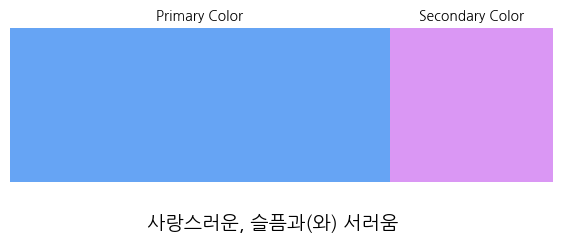

['슬픔', '서러움', '사랑스러운'] {'updated_primary_color': {'H': 214, 'S': '58', 'B': '96', 'color info': {'color_id': '19', 'term_id': '8', 'emotion_term': '슬픔', 'priority': '1', 'R': '76', 'G': '87', 'B': '101', 'reference_1': '김애경,and 오윤경. "긍정 및 부정 정서어휘에 대한 색 반응 연구." 조형미디어학 19.1 (2016): 59-66.', 'reference_2': 'https://gist.github.com/poet-developer/9291291c6dfb37053a9b59edef639393', 'reference_type': '한국성인', 'color_label': '남색', 'color_code': 'PB', 'KOTE_paired': 'yes', 'KOTE_id': '5', 'KOTE_emotion_term': '슬픔', 'reference_type_clean': '한국성인', 'ref_rank': 1, 'priority_num': 1}}, 'updated_secondary_color': {'H': 283, 'S': '38', 'B': '96', 'color info': {'color_id': '156', 'term_id': '54', 'emotion_term': 'sorrow', 'priority': '1', 'R': '101', 'G': '49', 'B': '121', 'reference_1': 'Claudia Cortes color extraction', 'reference_2': '공공디자인색채표준가이드', 'reference_type': '색채심리이론', 'color_label': '보라', 'color_code': 'P', 'KOTE_paired': 'yes', 'KOTE_id': '36', 'KOTE_emotion_term': '서러움', 'reference_type

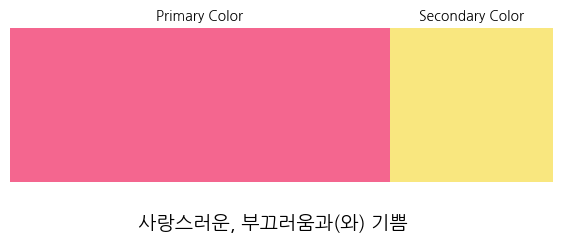

['부끄러움', '기쁨', '사랑스러운'] {'updated_primary_color': {'H': 343, 'S': '58', 'B': '96', 'color info': {'color_id': '96', 'term_id': '27', 'emotion_term': '부끄러움', 'priority': '1', 'R': '229', 'G': '193', 'B': '203', 'reference_1': '감정단어카드를 활용한 유아의 색채반응 연구 = A study on Color Reaction of Children utilizing Emotional Word Cards', 'reference_2': 'R(munsell pakage)', 'reference_type': '한국유아', 'color_label': '자주', 'color_code': 'RP', 'KOTE_paired': 'yes', 'KOTE_id': '17', 'KOTE_emotion_term': '부끄러움', 'reference_type_clean': '한국유아', 'ref_rank': 2, 'priority_num': 1}}, 'updated_secondary_color': {'H': 51, 'S': '49', 'B': '98', 'color info': {'color_id': '187', 'term_id': '64', 'emotion_term': '기쁨', 'priority': '1', 'R': '238', 'G': '201', 'B': '0', 'reference_1': '김애경,and 오윤경. "긍정 및 부정 정서어휘에 대한 색 반응 연구." 조형미디어학 19.1 (2016): 59-66.', 'reference_2': 'https://gist.github.com/poet-developer/9291291c6dfb37053a9b59edef639340', 'reference_type': '한국성인', 'color_label': '노랑', 'color_code': 'Y', 'KOTE_paired'

In [45]:
# emotion_to_colors(top_emotions_similar, updated_colors1)
# emotion_to_colors(top_emotions_contrast, updated_colors2)
# emotion_to_colors(top_emotions_similaremotion_contrastcolor, updated_colors3)
emotion_to_colors(top_emotions_similar, colors_similar)
emotion_to_colors(top_emotions_contrast, colors_contrast)

## KPoEM 감정분류 모델 로드

In [46]:
!pip install langchain langchain-community langchain-core

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/bitsandbytes-0.45.4.dev0-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.0.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg a

In [47]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import os
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import pytorch_lightning as pl
import torch
torch.set_float32_matmul_precision('medium')
import torch.nn as nn
from transformers import ElectraModel, AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from huggingface_hub import hf_hub_download

In [48]:
# 기초 세팅
REPO_ID = "AKS-DHLAB/KPoEM" # 허깅페이스에 업로드된 감정분류모델 id
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") #GPU 사용
THRESH_HOLD = 0.3

In [49]:
# KPoEM_Classifier 클래스
class KPoEM_Classifier(nn.Module):
    def __init__(self, repo_id, device):
        self.labels = [
            '불평/불만', '환영/호의', '감동/감탄', '지긋지긋', '고마움', '슬픔', '화남/분노', '존경',
            '기대감', '우쭐댐/무시함', '안타까움/실망', '비장함', '의심/불신', '뿌듯함', '편안/쾌적',
            '신기함/관심', '아껴주는', '부끄러움', '공포/무서움', '절망', '한심함', '역겨움/징그러움',
            '짜증', '어이없음', '없음', '패배/자기혐오', '귀찮음', '힘듦/지침', '즐거움/신남', '깨달음',
            '죄책감', '증오/혐오', '흐뭇함(귀여움/예쁨)', '당황/난처', '경악', '부담/안_내킴', '서러움',
            '재미없음', '불쌍함/연민', '놀람', '행복', '불안/걱정', '기쁨', '안심/신뢰'
        ]
        num_labels = len(self.labels)
        #모델 & 토크나이저 로드
        super().__init__()
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained(repo_id) 
        self.electra = AutoModel.from_pretrained(repo_id)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.1),
            nn.Linear(self.electra.config.hidden_size, num_labels)
        )

        weights_path = hf_hub_download(repo_id=repo_id, filename="classifier_state.bin") #가중치 불러오기
        self.classifier.load_state_dict(torch.load(weights_path, map_location=self.device))
        self.to(self.device)
        self.eval()

    # 텍스트를 입력받아 최종 logits 반환
    def forward(self, text: str):
        encoding = self.tokenizer(
          text,
          add_special_tokens=True,
          max_length=512,
          padding="max_length",
          truncation=True,
          return_tensors='pt',
        ).to(self.device)

        with torch.no_grad():
            outputs = self.electra(
                input_ids=encoding["input_ids"],
                attention_mask=encoding["attention_mask"],
                token_type_ids=encoding["token_type_ids"]
            )

        pooled_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(pooled_output)
        return logits

    def analyze(self, text: str, threshold=0):
        logits = self.forward(text)
        probabilities = torch.sigmoid(logits.squeeze()) #확률로 변환 → threshold 이상이면 선택
        predictions = (probabilities > threshold).int()

        result_dict = {
            self.labels[i]: float(round(probabilities[i].item(), 3))
            for i, label_id in enumerate(predictions)
            if label_id == 1
        }

        # 확률값 기준 내림차순 정렬된 dict로 반환
        result_dict = dict(sorted(result_dict.items(), key=lambda x: x[1], reverse=True))
        return result_dict


In [50]:
# KPoEM 모델 로드
print(f"... '{DEVICE}' 환경에서 '{REPO_ID}' 모델을 로드하고 있습니다 ...")
kpoem_model = KPoEM_Classifier(repo_id=REPO_ID, device=DEVICE)
print("KPoEM 모델을 성공적으로 로드하였습니다.")

... 'cuda' 환경에서 'AKS-DHLAB/KPoEM' 모델을 로드하고 있습니다 ...
KPoEM 모델을 성공적으로 로드하였습니다.


In [51]:
sample_text = """
날이 흐리고 풀이 눕는다
발목까지
발밑까지 눕는다
바람보다 늦게 누워도
바람보다 먼저 일어나고
바람보다 늦게 울어도
바람보다 먼저 웃는다
날이 흐리고 풀뿌리가 눕는다.
""" # 송몽규 - 하늘과 더불어

In [52]:
poem_emotions = kpoem_model.analyze(sample_text, threshold=THRESH_HOLD)
poem_emotions

{'흐뭇함(귀여움/예쁨)': 0.809,
 '기쁨': 0.804,
 '슬픔': 0.756,
 '행복': 0.74,
 '서러움': 0.72,
 '편안/쾌적': 0.711,
 '감동/감탄': 0.71,
 '신기함/관심': 0.676,
 '깨달음': 0.672,
 '기대감': 0.634,
 '아껴주는': 0.575,
 '힘듦/지침': 0.563,
 '즐거움/신남': 0.558,
 '불안/걱정': 0.469,
 '안타까움/실망': 0.409,
 '뿌듯함': 0.396,
 '환영/호의': 0.367,
 '불쌍함/연민': 0.367}

## 3. Langchain (Blossom)

In [53]:
!pip install --upgrade langchain

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/bitsandbytes-0.45.4.dev0-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.0.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg a

### KT-Midm

In [54]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "K-intelligence/Midm-2.0-Base-Instruct"
CACHE_DIR = "../model/Midm"   # 바꿀 경로

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype="bfloat16",
    device_map="auto",
    trust_remote_code=True,
    cache_dir=CACHE_DIR
)

device = model.device


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

#### 컨텍스트 엔지니어링

In [55]:
# 중복 제거 후 정렬
adjectives = sorted(df_IRI['형용사'].dropna().unique())
# 배열을 콤마 구분 문자열로 변환
adjectives_str = ",".join(adjectives)

print(adjectives_str)

가벼운,가지런한,간편한,감각적인,감미로운,감성적인,강인한,강한,개성적인,거친,건실한,격식있는,견고한,고급스러운,그윽한,기능적인,기운찬,깊은,깔끔한,나이든,남성적인,넉넉한,다양한,단순한,단정한,달콤한,도시적인,돋보이는,동양적인,동적인,딱딱한,뛰어난,맑은,매끄러운,매력적인,멋진,무거운,밝은,보수적인,복잡한,부드러운,사랑스러운,상쾌한,새로운,서양적인,선명한,섬세한,성숙한,세련된,소박한,수수한,순수한,스포티한,시원한,신선한,실용적인,심플한,싱싱한,아기자기한,안정된,약한,얕은,어두운,여성적인,여유있는,연약한,오래된,와일드한,우울한,유연한,율동적인,이성적인,인공적인,자연적인,자유로운,잔잔한,장식적인,재미있는,전원적인,전통적인,젊은,정다운,정돈된,정적인,조용한,중후한,즐거운,지적인,진보적인,차가운,차분한,친근한,쾌활한,클래식한,탁한,투명한,편리한,편안한,포근한,품위있는,풍성한,하이테크한,한국적인,향기로운,혁신적인,환상적인,활동적인


In [56]:
# import torch.nn.functional as F

# def score_labels_by_logprob(poem: str, labels: list[str], batch_size: int = 32):
#     # 프롬프트: '정답:' 뒤를 라벨로 채워넣어 점수화
#     base_prompt = (
#         "너는 시를 읽는 독자야. 너는 주어진 시를 감상하고 시에 가장 의미적으로 어울리는 라벨 중 하나만 고른다\n"
#         f"허용 라벨: {', '.join(labels)}\n\n시:\n{poem}\n\n정답:"
#     )
#     # 고정 프롬프트 길이(토큰)
#     prompt_ids = tokenizer(base_prompt, return_tensors="pt").input_ids.to(device)
#     prompt_len = prompt_ids.shape[1]

#     scores = []
#     # 배치로 후보 점수화 (전체 106개도 충분히 빠름)
#     for i in range(0, len(labels), batch_size):
#         batch_labels = labels[i:i+batch_size]
#         texts = [base_prompt + lab for lab in batch_labels]
#         enc = tokenizer(texts, return_tensors="pt", padding=True).to(device)
#         with torch.no_grad():
#             out = model(**enc)
#             logits = out.logits  # [B, T, V]
#             logp = F.log_softmax(logits[:, :-1, :], dim=-1)     # predict next token
#             next_ids = enc.input_ids[:, 1:]                     # gold next tokens

#         # 각 샘플별로 '라벨 토큰' 구간만 합산
#         B, Tm1 = next_ids.shape
#         for b in range(B):
#             seq_len = enc.input_ids[b].shape[0]
#             label_tok_start = prompt_len - 1                    # 첫 예측 위치
#             label_tok_end   = seq_len - 1                       # 마지막 예측 위치(포함)
#             idx = torch.arange(Tm1, device=device)
#             mask = (idx >= label_tok_start) & (idx <= label_tok_end)
#             row_logp = logp[b].gather(-1, next_ids[b].unsqueeze(-1)).squeeze(-1)
#             score = row_logp[mask].sum().item()
#             scores.append((batch_labels[b], score))

#     # 점수 내림차순
#     scores.sort(key=lambda x: x[1], reverse=True)
#     print(scores)
#     return scores

# def classify_poem(poem: str, labels: list[str]) -> str:
#     scores = score_labels_by_logprob(poem, labels)
#     return scores[0][0]

# # # 예시
# # poem = "미풍에 웃는 아칭을 기원하련다"
# # print(classify_poem(poem, adjectives))


In [57]:
import torch.nn.functional as F

@torch.inference_mode()
def score_labels_by_logprob(poem: str, labels: list[str], batch_size: int = 8, max_length: int = 512):
    base_prompt = (
        "너는 시를 읽는 독자야. 너는 주어진 시를 감상하고 시에 가장 의미적으로 어울리는 라벨 중 하나만 고른다\n"
        f"허용 라벨: {', '.join(labels)}\n\n시:\n{poem}\n\n정답:"
    )

    # base_prompt 토큰 길이 (라벨 첫 토큰 시작점 계산용)
    prompt_ids = tokenizer(base_prompt, return_tensors="pt", truncation=True, max_length=max_length).input_ids.to(device)
    prompt_len = prompt_ids.shape[1]  # base_prompt의 토큰 수

    scores = []

    model.eval()

    for i in range(0, len(labels), batch_size):
        batch_labels = labels[i:i+batch_size]
        texts = [base_prompt + lab for lab in batch_labels]

        enc = tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        ).to(device)

        out = model(**enc)
        logits = out.logits  # [B, T, V]

        # next-token prediction: logits for positions 0..T-2 predict tokens 1..T-1
        shift_logits = logits[:, :-1, :].contiguous()     # [B, T-1, V]
        shift_labels = enc.input_ids[:, 1:].contiguous()  # [B, T-1]
        attn = enc.attention_mask[:, 1:].contiguous()     # [B, T-1] (패딩 토큰 0)

        # ✅ 메모리 효율적으로 per-token NLL 계산: [B, T-1]
        # cross_entropy 입력은 [B, V, T-1] 형태가 편함
        nll = F.cross_entropy(
            shift_logits.transpose(1, 2),   # [B, V, T-1]
            shift_labels,                   # [B, T-1]
            reduction="none"
        )  # [B, T-1]  (값은 -log p)

        # 라벨 토큰 구간만 합산
        # label starts at (prompt_len - 1) in the shifted timeline
        label_start = prompt_len - 1

        for b in range(shift_labels.size(0)):
            # 실제 길이 (패딩 제외)
            seq_len = int(enc.attention_mask[b].sum().item())  # input_ids 기준 길이
            # shifted timeline 길이는 seq_len-1
            label_end = (seq_len - 1) - 1  # 마지막 예측 인덱스 = (seq_len-2)

            if label_start > label_end:
                scores.append((batch_labels[b], float("-inf")))
                continue

            idx = torch.arange(shift_labels.size(1), device=device)
            mask = (idx >= label_start) & (idx <= label_end) & (attn[b] == 1)

            # score = sum(logp) = -sum(nll)
            score = (-nll[b][mask]).sum().item()
            scores.append((batch_labels[b], score))

        # (선택) 배치마다 캐시 정리 (OOM 계속 나면 켜기)
        # torch.cuda.empty_cache()

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores

def classify_poem(poem: str, labels: list[str]) -> str:
    scores = score_labels_by_logprob(poem, labels)
    return scores[0][0]


## Co-Reading

In [68]:
# 8️⃣ 전체 체인
def CoReadingPoem(user_input, adjectives):
    CoReading_Result = classify_poem(user_input, adjectives) #LLM
    print(CoReading_Result)
    poem_emotions = kpoem_model.analyze(user_input, threshold=THRESH_HOLD)
    print(poem_emotions)
    poem_colors = define_colors(poem_emotions, CoReading_Result , df_paired, IRI_colors_df)
    emotion_to_colors([poem_colors['primary_emotion'],poem_colors['secondary_emotion'], CoReading_Result], poem_colors)

깊은
{'안타까움/실망': 0.882, '비장함': 0.859, '슬픔': 0.841, '깨달음': 0.81, '서러움': 0.789, '불안/걱정': 0.768, '의심/불신': 0.646, '불평/불만': 0.541, '불쌍함/연민': 0.533, '절망': 0.508, '기대감': 0.506, '존경': 0.491, '부담/안_내킴': 0.44, '아껴주는': 0.436, '한심함': 0.412, '힘듦/지침': 0.388, '당황/난처': 0.346, '패배/자기혐오': 0.343, '감동/감탄': 0.338, '신기함/관심': 0.306, '놀람': 0.304}
Primary: negative, Secondary: neutral
형용사 '깊은'는 '모던한' 형용사군에 속합니다.
선택된 배색그룹id: 4
디버깅중 {'H': 208, 'S': 78, 'B': 32, 'color info': {'color_id': '47', 'term_id': '18', 'emotion_term': '애통', 'priority': '1', 'R': '18', 'G': '52', 'B': '82', 'reference_1': '김애경,and 오윤경. "긍정 및 부정 정서어휘에 대한 색 반응 연구." 조형미디어학 19.1 (2016): 59-66.', 'reference_2': 'https://gist.github.com/poet-developer/9291291c6dfb37053a9b59edef639403', 'reference_type': '한국성인', 'color_label': '남색', 'color_code': 'PB', 'KOTE_paired': 'yes', 'KOTE_id': '10', 'KOTE_emotion_term': '안타까움/실망', 'reference_type_clean': '한국성인', 'ref_rank': 1, 'priority_num': 1}} {'H': 26, 'S': 94, 'B': 92, 'color info': {'color_id': '64',

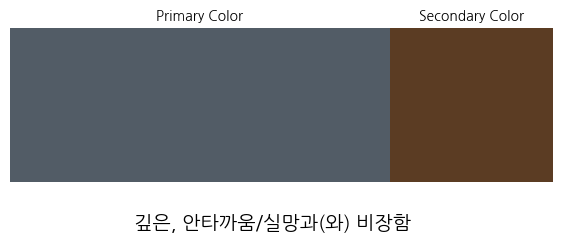

['안타까움/실망', '비장함', '깊은'] {'updated_primary_color': {'H': 208, 'S': '19', 'B': '40', 'color info': {'color_id': '47', 'term_id': '18', 'emotion_term': '애통', 'priority': '1', 'R': '18', 'G': '52', 'B': '82', 'reference_1': '김애경,and 오윤경. "긍정 및 부정 정서어휘에 대한 색 반응 연구." 조형미디어학 19.1 (2016): 59-66.', 'reference_2': 'https://gist.github.com/poet-developer/9291291c6dfb37053a9b59edef639403', 'reference_type': '한국성인', 'color_label': '남색', 'color_code': 'PB', 'KOTE_paired': 'yes', 'KOTE_id': '10', 'KOTE_emotion_term': '안타까움/실망', 'reference_type_clean': '한국성인', 'ref_rank': 1, 'priority_num': 1}}, 'updated_secondary_color': {'H': 26, 'S': '61', 'B': '36', 'color info': {'color_id': '64', 'term_id': '20', 'emotion_term': 'determination', 'priority': '1', 'R': '235', 'G': '111', 'B': '14', 'reference_1': 'Claudia Cortes color extraction', 'reference_2': '공공디자인색채표준가이드', 'reference_type': '색채심리이론', 'color_label': '주황', 'color_code': 'YR', 'KOTE_paired': 'yes', 'KOTE_id': '11', 'KOTE_emotion_term': '비장함', '

In [70]:
# 미풍이 웃는 아침을 기원하련다
CoReadingPoem("""자유를 위해서
비상(飛翔)하여 본 일이 있는
사람이면 알지.
노고지리가
무엇을 보고
노래하는가를
어째서 자유에는
피 냄새가 섞여 있는가를
혁명(革命)은
왜 고독한 것인가를""", adjectives)